# Notebook 05 — Priority Classification

**Input:** Pre-processed TF-IDF features from Notebook 03  
**Target:** `priority` — Low / Medium / High / Critical  
**Models:** Random Forest + Gradient Boosting on TF-IDF (best classical ML setup)

---
### Design Decision — Why No LSTM Here?

> In a real ITSM project, not every sub-problem needs the full model suite. Priority classification shares the same input (ticket text → TF-IDF) and the same challenge (class imbalance) as category classification. We already established in Notebook 04 that TF-IDF + ensemble methods outperform LSTM on this dataset size. Repeating the full LSTM experiment would not produce new architectural insights — it would only add engineering complexity without adding value. This is a deliberate, documented design decision — exactly the kind of trade-off senior engineers make in real projects.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS    = PROJECT_ROOT / 'models'
RESULTS   = PROJECT_ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1. Load Data

In [2]:
# ── TF-IDF features (same as Notebook 04) ────────────────────────────────────
X_train = sp.load_npz(str(PROCESSED / 'X_train_tfidf.npz'))
X_val   = sp.load_npz(str(PROCESSED / 'X_val_tfidf.npz'))
X_test  = sp.load_npz(str(PROCESSED / 'X_test_tfidf.npz'))

# ── Priority labels ───────────────────────────────────────────────────────────
y_train = np.load(str(PROCESSED / 'y_train_pri.npy'))
y_val   = np.load(str(PROCESSED / 'y_val_pri.npy'))
y_test  = np.load(str(PROCESSED / 'y_test_pri.npy'))

le_pri      = joblib.load(str(MODELS / 'label_encoder_priority.joblib'))
CLASS_NAMES = list(le_pri.classes_)
PRI_ORDER   = ['Low', 'Medium', 'High', 'Critical']

print(f'Train: {X_train.shape}  |  Classes: {CLASS_NAMES}')
print('Priority distribution (train):')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {le_pri.inverse_transform([u])[0]:10s}: {c} ({c/len(y_train)*100:.1f}%)')

Train: (2799, 2764)  |  Classes: ['Critical', 'High', 'Low', 'Medium']
Priority distribution (train):
  Critical  : 192 (6.9%)
  High      : 505 (18.0%)
  Low       : 976 (34.9%)
  Medium    : 1126 (40.2%)


---
## 2. Class Imbalance Analysis

Priority is more imbalanced than category — Low + Medium account for ~75% of tickets.
This makes `class_weight='balanced'` **essential**, not optional.

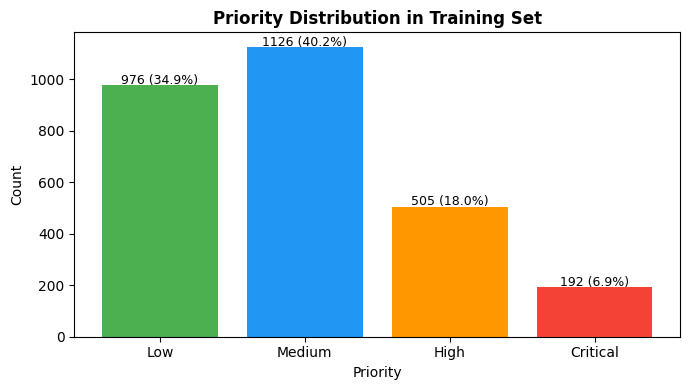

In [3]:
pri_counts = pd.Series(y_train).map(dict(enumerate(le_pri.classes_))).value_counts()
pri_counts  = pri_counts.reindex(PRI_ORDER)
colors = ['#4caf50','#2196f3','#ff9800','#f44336']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pri_counts.index, pri_counts.values, color=colors)
for bar, val in zip(bars, pri_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val} ({val/len(y_train)*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('Priority Distribution in Training Set', fontweight='bold')
ax.set_xlabel('Priority'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(RESULTS / 'pri_class_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. Evaluation Helper

In [4]:
results_log = []

def evaluate(y_true, y_pred, name):
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    wt_f1    = f1_score(y_true, y_pred, average='weighted')

    print(f'\n=== {name} ===')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(RESULTS / f'pri_{name.replace(" ","_")}_cm.png', bbox_inches='tight')
    plt.show()

    results_log.append({
        'Model': name, 'Accuracy': round(acc,4),
        'Macro_F1': round(macro_f1,4), 'Weighted_F1': round(wt_f1,4)
    })
    return acc, macro_f1

print('Evaluation helper ready.')

Evaluation helper ready.


---
## 4. Model 1 — Logistic Regression (Baseline)

Included as a baseline for comparison with ensemble methods.


=== Logistic Regression TF-IDF ===
              precision    recall  f1-score   support

    Critical       0.12      0.25      0.16        48
        High       0.49      0.44      0.46       110
         Low       0.57      0.47      0.51       196
      Medium       0.56      0.55      0.55       246

    accuracy                           0.48       600
   macro avg       0.44      0.43      0.42       600
weighted avg       0.51      0.48      0.49       600



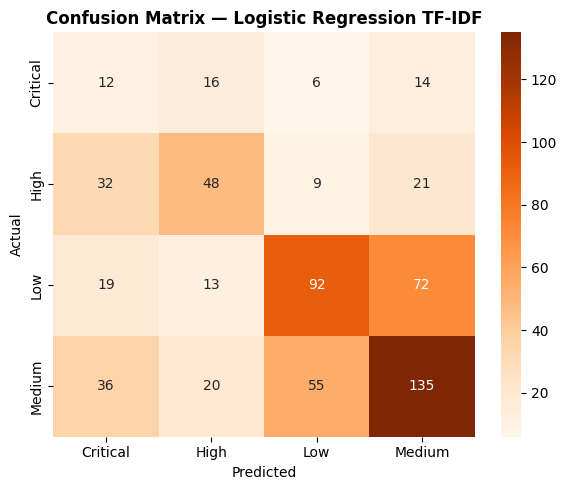

(0.47833333333333333, 0.4235696477589989)

In [5]:
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',   # compensates for Low/Medium dominance
    random_state=42,
    solver='lbfgs',
    n_jobs=-1,
)
lr.fit(X_train, y_train)
evaluate(y_test, lr.predict(X_test), 'Logistic Regression TF-IDF')

---
## 5. Model 2 — Random Forest

**`class_weight='balanced_subsample'`:** Each bootstrap sample used to grow a tree is re-balanced, so every tree sees equal class representation. More robust than a single global weight when the dataset has multiple minority classes.


=== Random Forest TF-IDF ===
              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00        48
        High       0.63      0.60      0.61       110
         Low       0.59      0.49      0.53       196
      Medium       0.58      0.76      0.66       246

    accuracy                           0.58       600
   macro avg       0.45      0.46      0.45       600
weighted avg       0.55      0.58      0.56       600



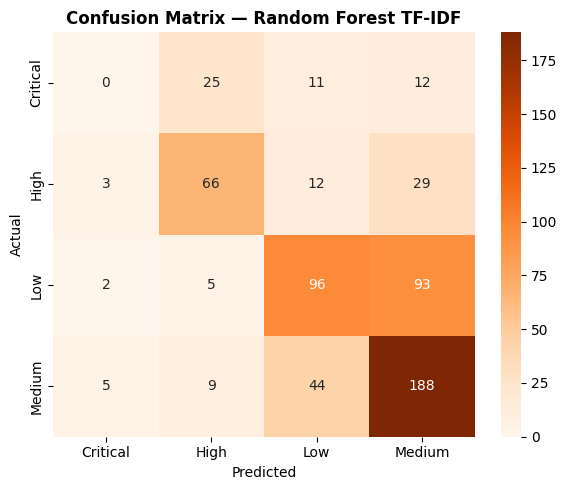

(0.5833333333333334, 0.4526860652155467)

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
evaluate(y_test, rf.predict(X_test), 'Random Forest TF-IDF')

---
## 6. Model 3 — Gradient Boosting

Gradient Boosting builds trees sequentially, each one correcting the errors of the previous. It is often the strongest performer on tabular/TF-IDF data but slower to train.

**Note:** We use `class_weight` via `sample_weight` instead, since sklearn's GBC doesn't support `class_weight` directly.


=== Gradient Boosting TF-IDF ===
              precision    recall  f1-score   support

    Critical       0.29      0.21      0.24        48
        High       0.56      0.53      0.54       110
         Low       0.69      0.44      0.54       196
      Medium       0.58      0.80      0.67       246

    accuracy                           0.58       600
   macro avg       0.53      0.49      0.50       600
weighted avg       0.59      0.58      0.57       600



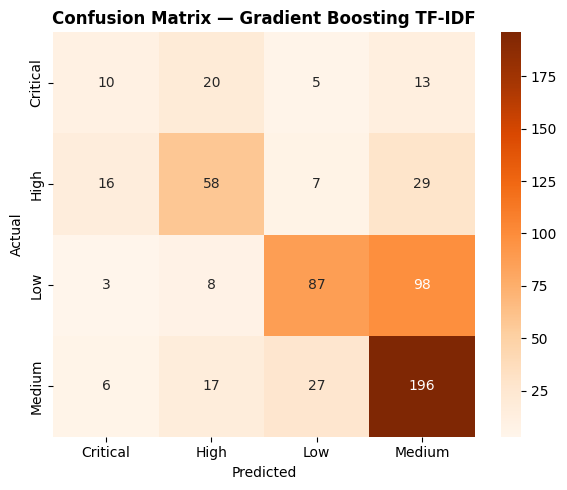

(0.585, 0.499869246024155)

In [7]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute per-sample weights from class frequencies
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
)
gb.fit(X_train, y_train, sample_weight=sample_weights)
evaluate(y_test, gb.predict(X_test), 'Gradient Boosting TF-IDF')

---
## 7. Comparison Table

In [8]:
results_df = pd.DataFrame(results_log).sort_values('Macro_F1', ascending=False).reset_index(drop=True)
results_df.index += 1
print('\n' + '='*55)
print('PRIORITY CLASSIFICATION — MODEL COMPARISON')
print('='*55)
print(results_df.to_string())
results_df.to_csv(RESULTS / 'priority_classification_results.csv')
print('\nSaved: results/priority_classification_results.csv')


PRIORITY CLASSIFICATION — MODEL COMPARISON
                        Model  Accuracy  Macro_F1  Weighted_F1
1    Gradient Boosting TF-IDF    0.5850    0.4999       0.5718
2        Random Forest TF-IDF    0.5833    0.4527       0.5587
3  Logistic Regression TF-IDF    0.4783    0.4236       0.4928

Saved: results/priority_classification_results.csv


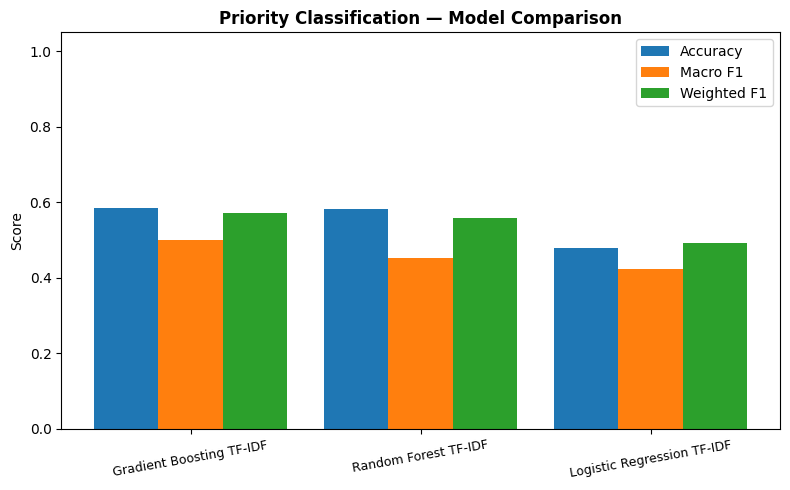

In [9]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.28
ax.bar(x - width, results_df['Accuracy'],    width, label='Accuracy')
ax.bar(x,         results_df['Macro_F1'],    width, label='Macro F1')
ax.bar(x + width, results_df['Weighted_F1'], width, label='Weighted F1')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=10, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Priority Classification — Model Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'priority_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 8. Save Best Priority Model

In [10]:
best_name = results_df.iloc[0]['Model']
model_map = {
    'Logistic Regression TF-IDF' : lr,
    'Random Forest TF-IDF'       : rf,
    'Gradient Boosting TF-IDF'   : gb,
}
best_pri_model = model_map[best_name]
joblib.dump(best_pri_model, str(MODELS / 'best_priority_model.joblib'))
print(f'Best priority model: {best_name}')
print('Saved: models/best_priority_model.joblib')

Best priority model: Gradient Boosting TF-IDF
Saved: models/best_priority_model.joblib


---
## Summary

| Artifact | Location |
|---|---|
| `priority_classification_results.csv` | `results/` |
| `pri_*_cm.png` | `results/` |
| `priority_model_comparison.png` | `results/` |
| `best_priority_model.joblib` | `models/` |

**Key insight:**
Priority classification is harder than category classification because priority labels are often ambiguous in real tickets — a user might not say 'urgent' even when the issue is critical. The `class_weight='balanced'` / `balanced_subsample` setting is what prevents the model from predicting Low/Medium for everything.

**Next:** Run `06_resolution_time_regression.ipynb`
